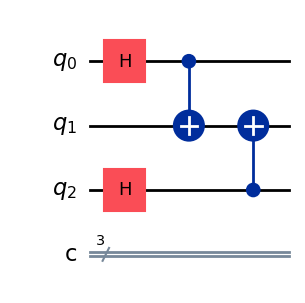

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


qc = QuantumCircuit(3,3)  # we want 2 qubits and then 2 cbits

qc.h([0,2])
qc.cx(0, 1)
qc.cx(2,1)
qc.draw(output='mpl')
 
 # this makes the bell state

In [2]:
qc.measure([0, 1, 2], [0, 1, 2])   # make the measurement of the qubit 0 at cbit 0 and qubit 1 at cbit 1

In [3]:
sim = AerSimulator()   # quantum computer simulator

In [4]:
result = sim.run(qc, shots=1000).result()   # shots = iterations
counts = result.get_counts()
print("Measurement outcomes:", counts)


Measurement outcomes: {'110': 242, '011': 253, '000': 257, '101': 248}


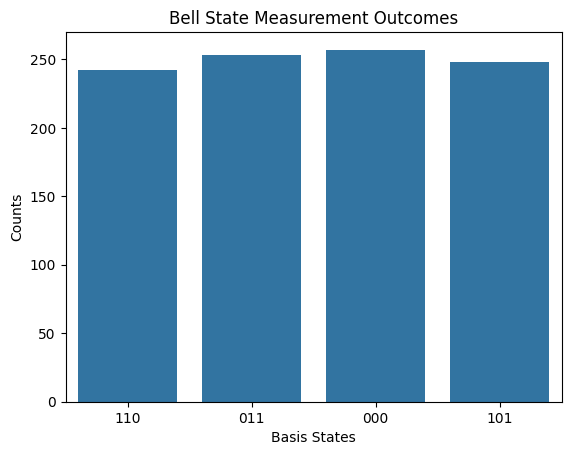

In [5]:
df = pd.DataFrame(list(counts.items()), columns=['State', 'Counts'])

sns.barplot(x='State', y='Counts', data=df)

plt.title("Bell State Measurement Outcomes")
plt.ylabel("Counts")
plt.xlabel("Basis States")
plt.show()

In [59]:
from qiskit.quantum_info import random_statevector

# Random 2-qubit state
psi = random_statevector(2**2)   # 2^2 = 4 dimensions

psi.sample_counts(shots=1000)

{np.str_('00'): np.int64(278),
 np.str_('01'): np.int64(495),
 np.str_('10'): np.int64(88),
 np.str_('11'): np.int64(139)}